  STEP 1 — LOAD TESTING AND TRAINING DATA  UNSW-NB15
  Training set: 175,341 rows x 43 columns
  Test set:     82,332 rows x 43 columns
  STEP 2  — DATA PREPARATION / PREPROCESS  
  Dropped 'state' column (train/test inconsistency)
  Encoded 'attack_cat' (10 classes)

  Subsample: 15,000 rows (for SVM + KNN)
  Full train: 175,341 rows (for tree-based models)
  Test set:   82,332 rows (same for all models)
  Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']

  STEP 3 : Training all models

  Training: SVM  ... done in 2136.2s  |  Accuracy: 64.28%

  Training: Random Forest ... done in 44.5s  |  Accuracy: 70.93%

  Training: Decision Tree ... done in 2.6s  |  Accuracy: 63.70%

  Training: XGB Classifier ... done in 33.8s  |  Accuracy: 73.06%
  STEP 4 — VALIDATE / EVALUATION MODEL

          Model Accuracy Precision Recall     F1  Zero-recall Train time Train Sample
XGB Classifier   73.06%    81.94% 73.06% 75.39%  

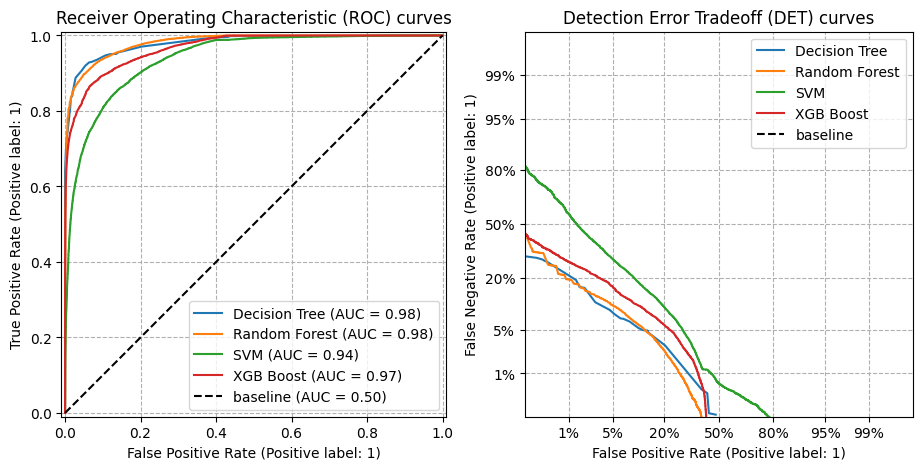

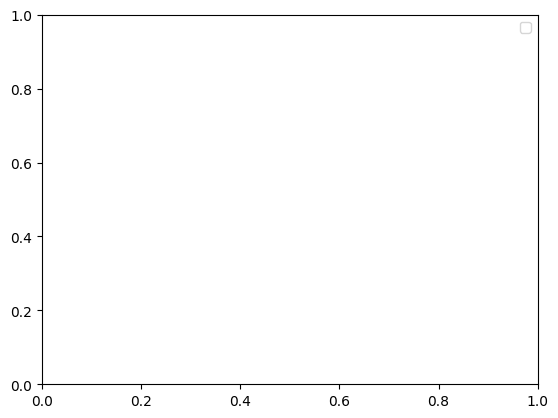



 Detailed report for best model — XGB Classifier
                precision    recall  f1-score   support

      Analysis       0.09      0.12      0.10       677
      Backdoor       0.03      0.05      0.04       583
           DoS       0.29      0.17      0.21      4089
      Exploits       0.61      0.86      0.71     11132
       Fuzzers       0.25      0.59      0.35      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.97      0.67      0.79     37000
Reconnaissance       0.93      0.81      0.86      3496
     Shellcode       0.50      0.48      0.49       378
         Worms       0.45      0.23      0.30        44

      accuracy                           0.73     82332
     macro avg       0.51      0.50      0.48     82332
  weighted avg       0.82      0.73      0.75     82332


  FINAL SUMMARY
      Random Forest                | F1:  75.41% | Acc:  70.93% | Zero-recall: 0 | 70% target: PASS
  >>> XGB Classifier               | F1:  75.

In [1]:
from sklearn.metrics import confusion_matrix
import time
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,det_curve,DetCurveDisplay, RocCurveDisplay)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import xgboost as xgb
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import export_text
from collections import OrderedDict
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

import warnings


warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD TESTING AND TRAINING DATA ,PREPROCESS
# ══════════════════════════════════════════════════════════════════════
print("="*60)
print("  STEP 1 — LOAD TESTING AND TRAINING DATA  UNSW-NB15")
print("="*60)

# Update these paths if your files are in a different location
train_file = 'UNSW_Training.csv'
test_file  = 'UNSW_test_File.csv'

df_train = pd.read_csv('UNSW_Training.csv')
df_test  = pd.read_csv('UNSW_test_File.csv')

print(f"  Training set: {df_train.shape[0]:,} rows x {df_train.shape[1]} columns")
print(f"  Test set:     {df_test.shape[0]:,} rows x {df_test.shape[1]} columns")

# ══════════════════════════════════════════════════════════════════════
# STEP 2  — DATA PREPARATION / PREPROCESS
# ══════════════════════════════════════════════════════════════════════
print("="*60)
print("  STEP 2  — DATA PREPARATION / PREPROCESS  ")
print("="*60)


for df in [df_train, df_test]:
    if 'state' in df.columns:
        df.drop(columns=['state'], inplace=True)
print("  Dropped 'state' column (train/test inconsistency)")

# Drop missing values
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

# Encode categorical columns
TARGET = 'attack_cat'
le_dict = {}
for col in df_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    le.fit(df_train[col])
    df_train[col] = le.transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])
    le_dict[col] = le
    print(f"  Encoded '{col}' ({len(le.classes_)} classes)")

# Separate features and target
X_train_full = df_train.drop(columns=[TARGET])
y_train_full = df_train[TARGET]
X_test  = df_test.drop(columns=[TARGET])
y_test  = df_test[TARGET]

# Stratified subsample for SVM and KNN (they're slow on full data)
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=15000, stratify=y_train_full, random_state=42
)

# Scale features — fit on training subsample, transform everything
scaler = StandardScaler()
scaler.fit(X_train_small)

X_train_small_scaled = scaler.transform(X_train_small)
X_train_full_scaled  = scaler.transform(X_train_full)
X_test_scaled        = scaler.transform(X_test)

print(f"\n  Subsample: {X_train_small_scaled.shape[0]:,} rows (for SVM + KNN)")
print(f"  Full train: {X_train_full_scaled.shape[0]:,} rows (for tree-based models)")
print(f"  Test set:   {X_test_scaled.shape[0]:,} rows (same for all models)")

# Class names for reports
class_names = le_dict[TARGET].classes_
print(f"  Classes: {list(class_names)}")
print()

# ══════════════════════════════════════════════════════════════════════
# STEP 3 — Training  all model
# ══════════════════════════════════════════════════════════════════════

print("="*60)
print("  STEP 3 : Training all models")
print("="*60)



models = [


    (
        'SVM ',
         SVC(kernel='rbf', C=1.0, gamma='scale',class_weight='balanced'),
        'full',

    ),

   (
        'Random Forest',
        RandomForestClassifier(n_estimators=100, max_depth= 25 ,class_weight='balanced', random_state=30,n_jobs=-1 ,max_features="sqrt"),
        'full'

    ),


    (
        'Decision Tree',
        DecisionTreeClassifier(max_depth=8,class_weight='balanced',
                                random_state=30,),
        'full'
    ),
    (
        'XGB Classifier',
        xgb.XGBClassifier(objective='multi:softmax', num_class=len(le.classes_),random_state=30),
        'full'

    )

]

results = []


for name, clf, data_size  in models:
    print(f"\n  Training: {name} ...", end=' ')

    # Pick training data
    if data_size == 'small':
        X_tr = X_train_small_scaled
        y_tr = y_train_small
        rows_used = X_train_small_scaled.shape[0]
    else:
        X_tr = X_train_full_scaled
        y_tr = y_train_full
        rows_used = X_train_full_scaled.shape[0]

 # Train
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - t0

    # Predict on full test set
    t1 = time.time()
    y_pred = clf.predict(X_test_scaled)
    predict_time = time.time() - t1

    # Evaluate
    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    f1w  = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

    # Per-class F1
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
    zero_recall_count = sum(1 for r in recall_score(
        y_test, y_pred, average=None, zero_division=0) if r == 0)

    print(f"done in {train_time:.1f}s  |  Accuracy: {acc:.2f}%")

    results.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1 (%)': round(f1w, 2),
        'Zero-recall classes': zero_recall_count,
        'Train time (s)': round(train_time, 1),
        'Predict time (s)': round(predict_time, 1),
        'Train Sample': f'{rows_used:,}',
        'y_pred': y_pred,
        'f1_per_class': f1_per_class

    })
df_results = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': f"{r['Accuracy (%)']:.2f}%",
    'Precision': f"{r['Precision (%)']:.2f}%",
    'Recall': f"{r['Recall (%)']:.2f}%",
    'F1': f"{r['F1 (%)']:.2f}%",
    'Zero-recall': r['Zero-recall classes'],
    'Train time': f"{r['Train time (s)']:.1f}s",
    'Train Sample': r['Train Sample'],
} for r in results])



y_Train_encoded_DET=y_train_full.map({0 : 1, 1 : 1, 2 : 1 , 3:1, 4:1, 5:1, 6:0, 7:1, 8:1, 9:1,10:1})
y_Test_encoded_DET=y_test.map({0 : 1, 1 : 1, 2 : 1 , 3:1, 4:1, 5:1, 6:0, 7:1, 8:1, 9:1,10:1})


DET_Model = {
    "Decision Tree":DecisionTreeClassifier(max_depth=7,random_state=8,class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=25 ,class_weight='balanced', random_state=30,n_jobs=-1 ),
        "SVM"  :SVC(kernel='rbf', C=1.0, gamma='scale',class_weight='balanced'),
    "XGB Boost": xgb.XGBClassifier(objective='binary:logistic' ,random_state=30,scale_pos_weight=1),
    "baseline": DummyClassifier()


}

fig, [ax_roc, ax_det] = plt.subplots(1, 2, figsize=(11, 5))

ax_roc.set_title("Receiver Operating Characteristic (ROC) curves")
ax_roc.grid(linestyle="--")
ax_det.set_title("Detection Error Tradeoff (DET) curves")
ax_det.grid(linestyle="--")

for name, clf_Curve in DET_Model.items():

  (color, linestyle) = (("black", "--") if name == "baseline" else (None, None))

  clf_Curve.fit(X_train_full_scaled, y_Train_encoded_DET)
  DetCurveDisplay.from_estimator(
        clf_Curve,X_test_scaled, y_Test_encoded_DET, ax=ax_det, name=name, color=color,linestyle=linestyle
    ),
  RocCurveDisplay.from_estimator(
        clf_Curve,
        X_test_scaled,
        y_Test_encoded_DET,
        ax=ax_roc,
        name=name,
        linestyle=linestyle,
        color=color


    )




# ══════════════════════════════════════════════════════════════════════
# STEP 4 — VALIDATE / EVALUATION MODEL
# ══════════════════════════════════════════════════════════════════════

print("="*60)
print("  STEP 4 — VALIDATE / EVALUATION MODEL")
print("="*60)
# Sort by F1 descending
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n", df_results.to_string(index=False))

best = max(results, key=lambda r: r['Accuracy (%)'])


# ══════════════════════════════════════════════════════════════════════
#  COMPARISON CHARTS & TABLES
# ══════════════════════════════════════════════════════════════════════

# Sort results by F1 for charts
results_sorted = sorted(results, key=lambda r: r['F1 (%)'], reverse=True)
model_names = [r['Model'] for r in results_sorted]

fig1 = go.Figure()

colors = ['#534AB7', '#1D9E75', '#378ADD', '#D85A30', '#BA7517', '#D4537E']
acc_vals = [r['Accuracy (%)'] for r in results_sorted]

fig1.add_trace(go.Bar(
    x=model_names, y=acc_vals,
    marker_color=colors[:len(model_names)],
    text=[f'{v:.1f}%' for v in acc_vals],
    textposition='outside', textfont=dict(size=11)
))
fig1.add_hline(y=70, line_dash='dash', line_color='#E24B4A',
               annotation_text='70% target')
fig1.update_layout(
    title='Overall accuracy — all models',
    yaxis=dict(range=[0, max(acc_vals)*1.15], title='Accuracy (%)'),
    height=380, margin=dict(t=60, b=100, l=50, r=30),
    xaxis=dict(tickangle=-20)
)
fig1.show()


f1_vals = [r['F1 (%)'] for r in results_sorted]



fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=model_names, y=f1_vals,
    marker_color=colors[:len(model_names)],
    text=[f'{v:.1f}%' for v in f1_vals],
    textposition='outside', textfont=dict(size=11)
))
fig2.add_hline(y=70, line_dash='dash', line_color='#E24B4A',
               annotation_text='70% target')
fig2.update_layout(
    title='Weighted F1 score — all models',
    yaxis=dict(range=[0, max(f1_vals)*1.15], title='F1 (%)'),
    height=380, margin=dict(t=60, b=100, l=50, r=30),
    xaxis=dict(tickangle=-20)
)

f1_vals = [r['F1 (%)'] for r in results_sorted]

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=model_names, y=f1_vals,
    marker_color=colors[:len(model_names)],
    text=[f'{v:.1f}%' for v in f1_vals],
    textposition='outside', textfont=dict(size=11)
))
fig2.add_hline(y=70, line_dash='dash', line_color='#E24B4A',
               annotation_text='70% target')
fig2.update_layout(
    title='Weighted F1 score — all models',
    yaxis=dict(range=[0, max(f1_vals)*1.15], title='F1 (%)'),
    height=380, margin=dict(t=60, b=100, l=50, r=30),
    xaxis=dict(tickangle=-20)
)
fig2.show()


# ── CHART 3: Precision vs Recall vs F1 grouped ──────────────────────
fig3 = go.Figure()
fig3.add_trace(go.Bar(name='Precision',
    x=model_names,
    y=[r['Precision (%)'] for r in results_sorted],text=[f'{v:.1f}%' for v in [r['Precision (%)'] for r in results_sorted] ],
    textposition='outside', textfont=dict(size=11),
    marker_color='#534AB7'))
fig3.add_trace(go.Bar(name='Recall',
    x=model_names,
    y=[r['Recall (%)'] for r in results_sorted],text=[f'{v:.1f}%' for v in [r['Recall (%)'] for r in results_sorted] ],
    textposition='outside', textfont=dict(size=11),
    marker_color='#D85A30'))
fig3.add_trace(go.Bar(name='F1',
    x=model_names,
    y=[r['F1 (%)'] for r in results_sorted],text=[f'{v:.1f}%' for v in [r['F1 (%)'] for r in results_sorted] ],
    textposition='outside', textfont=dict(size=11),
    marker_color='#1D9E75'))
fig3.update_layout(
    title='Precision vs recall vs F1 — all models',
    barmode='group',
    yaxis=dict(range=[0, 105], title='Score (%)'),
    height=400, margin=dict(t=60, b=100, l=50, r=30),
    legend=dict(x=0.75, y=0.95), xaxis=dict(tickangle=-20)
)

fig3.show()



zero_counts = [r['Zero-recall classes'] for r in results_sorted]

fig4 = go.Figure()
fig4.add_trace(go.Bar(
    x=model_names, y=zero_counts,
    marker_color=['#1D9E75' if z == 0 else '#BA7517' if z <= 2
                  else '#E24B4A' for z in zero_counts],
    text=zero_counts, textposition='outside'
))
fig4.update_layout(
    title='Number of attack classes with zero recall (lower is better)',
    yaxis=dict(title='Classes with zero recall', dtick=1),
    height=350, margin=dict(t=60, b=100, l=50, r=30),
    xaxis=dict(tickangle=-20)
)
fig4.show()




f1_matrix = []
for r in results_sorted:
    f1_matrix.append([round(f, 2) for f in r['f1_per_class']])

fig5 = go.Figure(go.Heatmap(
    z=f1_matrix,
    x=list(class_names),
    y=model_names,
    colorscale='RdYlGn',
    zmin=0, zmax=1,
    text=[[f'{v:.2f}' for v in row] for row in f1_matrix],
    texttemplate='%{text}',
    textfont=dict(size=10),
    hovertemplate='Model: %{y}<br>Class: %{x}<br>F1: %{z:.2f}<extra></extra>'
))
fig5.update_layout(
    title='Per-class F1 score — all models (green = good, red = bad)',
    height=350, margin=dict(t=60, b=100, l=180, r=30),
    xaxis=dict(tickangle=-30)
)
fig5.show()

train_times = [r['Train time (s)'] for r in results_sorted]

fig6 = go.Figure()
fig6.add_trace(go.Bar(
    x=model_names, y=train_times,
    marker_color='#888780',
    text=[f'{t:.1f}s' for t in train_times],
    textposition='outside'
))
fig6.update_layout(
    title='Training time (seconds)',
    yaxis=dict(title='Time (s)'),
    height=350, margin=dict(t=60, b=100, l=50, r=30),
    xaxis=dict(tickangle=-20)
)
fig6.show()


fig7 = go.Figure()
fig7.add_trace(go.Bar(
    x=['Train','Test'],y=[X_train_full_scaled.shape[0],X_test_scaled.shape[0]],
    textfont=dict(size=11),text=[X_train_full_scaled.shape[0],X_test_scaled.shape[0]]  , texttemplate=['%{y}','%{y}'],
    textposition='outside'))
fig7.update_layout(
    title='Train and Test Sample',
    height=350, margin=dict(t=60, b=100, l=180, r=30),yaxis=dict(range=[0,200000], title='Sample #'),
    xaxis=dict(tickangle=-30))
fig7.show()


# DET and ROC Graph
plt.legend()
plt.show()


# DET and ROC Graph
plt.legend()
plt.show()

# ══════════════════════════════════════════════════════════════════════
#  Detailed report for best model - Best
# ══════════════════════════════════════════════════════════════════════



print("\n\n" + "="*60)
print(f" Detailed report for best model — {best['Model']}")
print("="*60)
print(classification_report(y_test, best['y_pred'],
                            target_names=class_names, zero_division=0))


# ══════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)

for r in results_sorted:
    marker = ">>>" if r['Model'] == best['Model'] else "   "
    target_hit = "PASS" if r['Accuracy (%)'] >= 70 else "FAIL"
    print(f"  {marker} {r['Model']:<28} | F1: {r['F1 (%)']:6.2f}% | "
          f"Acc: {r['Accuracy (%)']:6.2f}% | "
          f"Zero-recall: {r['Zero-recall classes']} | "
          f"70% target: {target_hit}"
          )


print(f"\n  BEST MODEL: {best['Model']}")
print(f"  Reason: Highest Accuracy  ({best['Accuracy (%)']:.2f}%) and F1-Score  ({best['F1 (%)']:.2f}%)")

if best['Accuracy (%)'] >= 70:
    print(f"  The 70% accuracy target is MET ({best['Accuracy (%)']:.2f}%)")
else:
    gap = 70 - best['Accuracy (%)']
    print(f"  The 70% accuracy target is NOT YET MET "
          f"({best['Accuracy (%)']:.2f}%, gap: {gap:.2f}pp)")
    print(f"  Next steps: hyperparameter tuning, SMOTE, or feature engineering")




# ══════════════════════════════════════════════════════════════════════
# CONCLUSION CLASSIFIED
# ══════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print(f" CONCLUSION CLASSIFIED BY {best['Model']} MODEL")
print("="*60)


sample = X_test.iloc[0:10]
sample_dict = sample.iloc[7].to_dict()
print(f"\nSample Traffics: {sample_dict }")

y_pred = clf.predict(sample)
y_pred_labels = le.inverse_transform(y_pred)
print(f"\n best {best['Model']}Model Predicted =", y_pred_labels[7])